Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textwrap import dedent
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, confusion_matrix, make_scorer, f1_score, precision_score, recall_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import statsmodels.api as sm

from joblib import dump, load

plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 100)


Loading Data

In [ ]:
# ---------- Load ----------
df = pd.read_csv('/content/sample_data/bank-additional-full.csv', sep=';')
print(f"Loaded shape: {df.shape}")
print("\nColumns:", list(df.columns))

# ---------- Quick peek ----------
print("\nHead:")
display(df.head())


Loaded shape: (41188, 21)

Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Head:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Cleaning Macroeconomic Data

In [ ]:
# ================================================
# Rename macroeconomic variables for readability
# ================================================

rename_map = {
    'emp.var.rate': 'emp_var',
    'cons.price.idx': 'price_idx',
    'cons.conf.idx': 'conf_idx',
    'euribor3m': 'euribor_rate',
    'nr.employed': 'num_employed'
}

df.rename(columns=rename_map, inplace=True)
print("Renamed macroeconomic variables for clarity.")

# Verify new column names
print(df.columns.tolist())


Renamed macroeconomic variables for clarity.
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_var', 'price_idx', 'conf_idx', 'euribor_rate', 'num_employed', 'y']


Variable Description Table

In [ ]:
var_descriptions = {
    'age': 'Age of the client (numeric)',
    'job': 'Type of job (categorical)',
    'marital': 'Marital status (categorical)',
    'education': 'Level of education (ordinal categorical)',
    'default': 'Has credit in default? (categorical: yes, no, unknown)',
    'housing': 'Has housing loan? (categorical: yes, no, unknown)',
    'loan': 'Has personal loan? (categorical: yes, no, unknown)',
    'contact': 'Communication type (telephone or cellular)',
    'month': 'Last contact month of year',
    'day_of_week': 'Last contact day of the week',
    'duration': 'Last contact duration in seconds (numeric — leakage variable)',
    'campaign': 'Number of contacts during this campaign (numeric)',
    'pdays': 'Days since last contact from a previous campaign (999 = not previously contacted)',
    'previous': 'Number of contacts before this campaign (numeric)',
    'poutcome': 'Outcome of the previous marketing campaign',
    'emp_var': 'Employment variation rate — quarterly indicator',
    'price_idx': 'Consumer price index — monthly indicator',
    'conf_idx': 'Consumer confidence index — monthly indicator',
    'euribor_rate': 'Euribor 3-month interest rate — daily indicator',
    'num_employed': 'Number of employed persons — quarterly indicator',
    'y': 'Target variable: has the client subscribed to a term deposit? (yes/no)'
}

desc_df = (
    pd.DataFrame({
        'Variable': var_descriptions.keys(),
        'Description': var_descriptions.values(),
        'Type': [df[col].dtype for col in var_descriptions.keys()],
        'Example Value': [df[col].iloc[0] for col in var_descriptions.keys()]
    })
)
display(desc_df.style.hide(axis='index').set_caption("Simplified Variable Description Table"))


Variable,Description,Type,Example Value
age,Age of the client (numeric),int64,56
job,Type of job (categorical),object,housemaid
marital,Marital status (categorical),object,married
education,Level of education (ordinal categorical),object,basic.4y
default,"Has credit in default? (categorical: yes, no, unknown)",object,no
housing,"Has housing loan? (categorical: yes, no, unknown)",object,no
loan,"Has personal loan? (categorical: yes, no, unknown)",object,no
contact,Communication type (telephone or cellular),object,telephone
month,Last contact month of year,object,may
day_of_week,Last contact day of the week,object,mon


Cleaning and Binning Data for EDA

In [ ]:
# Target to {0,1}
df['y_bin'] = (df['y'].str.lower().str.strip() == 'yes').astype(int)

# Identify types (per data dictionary)
numeric_cols = [
    'age','duration','campaign','pdays','previous',
    'emp_var','price_idx','conf_idx','euribor_rate','num_employed'
]
cat_cols = [c for c in df.columns if c not in numeric_cols + ['y','y_bin']]

Checking Missing Values

In [ ]:
# ---------- Missing & "unknown" ----------
# Count explicit NaN
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nNaN counts:")
display(na_counts[na_counts > 0])

# In this dataset, many missing are encoded as 'unknown' in categoricals
def count_unknowns(frame, cols):
    out = []
    for c in cols:
        if frame[c].dtype == 'O':
            out.append((c, int((frame[c].str.lower() == 'unknown').sum())))
    return pd.DataFrame(out, columns=['column','unknown_count']).sort_values('unknown_count', ascending=False)

unknown_counts = count_unknowns(df, cat_cols)
print("\n'unknown' counts in categoricals:")
display(unknown_counts)


NaN counts:


,0



'unknown' counts in categoricals:


,column,unknown_count
3,default,8597
2,education,1731
4,housing,990
5,loan,990
0,job,330
1,marital,80
6,contact,0
7,month,0
8,day_of_week,0
9,poutcome,0


**Exploratory Data Analysis**

Class Balance

In [ ]:
# ---------- Class balance ----------
print("\nTarget distribution (y):")
display(df['y'].value_counts().to_frame('count').assign(share=lambda t: t['count']/len(df)).style.format({'share':'{:.2%}'}))


Target distribution (y):


,count,share
y,,
no,36548,88.73%
yes,4640,11.27%


Helper Functions

In [ ]:
# Helper: bar of target rate by category (sorted by support)
def bar_target_rate(frame, col, top=None):
    t = (frame.groupby(col, dropna=False)['y_bin']
                .agg(n='size', rate='mean')
                .reset_index()
                .sort_values('n', ascending=False))
    if top is not None:
        t = t.head(top)
    plt.figure()
    sns.barplot(data=t, x=col, y='rate', order=t[col].tolist())
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Subscription Rate')
    plt.title(f"Target rate by {col}")
    plt.tight_layout()
    plt.show()

# Helper: countplot (sorted by count)
def bar_count(frame, col, top=None):
    order = frame[col].value_counts(dropna=False).index.tolist()
    if top is not None:
        order = order[:top]
        frame = frame[frame[col].isin(order)]
    plt.figure()
    sns.countplot(data=frame, x=col, order=order)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Count of {col}")
    plt.tight_layout()
    plt.show()

# Helper: KDE split by target (for continuous)
def kde_by_target(frame, col):
    plt.figure()
    sns.kdeplot(data=frame, x=col, hue='y_bin', common_norm=False)
    plt.title(f"Distribution of {col} by target")
    plt.tight_layout()
    plt.show()

# Helper: boxplot by target (for continuous)
def box_by_target(frame, col):
    plt.figure()
    sns.boxplot(data=frame, x='y_bin', y=col)
    plt.xticks([0,1], ['no','yes'])
    plt.title(f"{col} by target (boxplot)")
    plt.tight_layout()
    plt.show()

Demographic Data

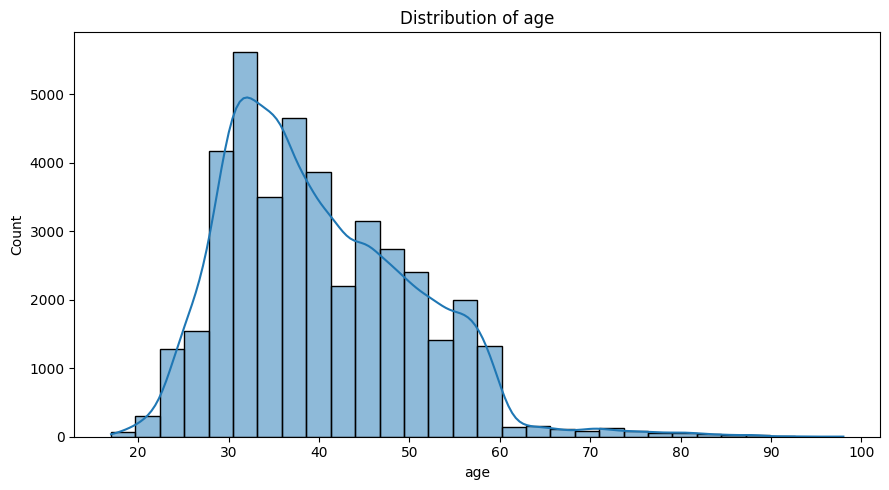

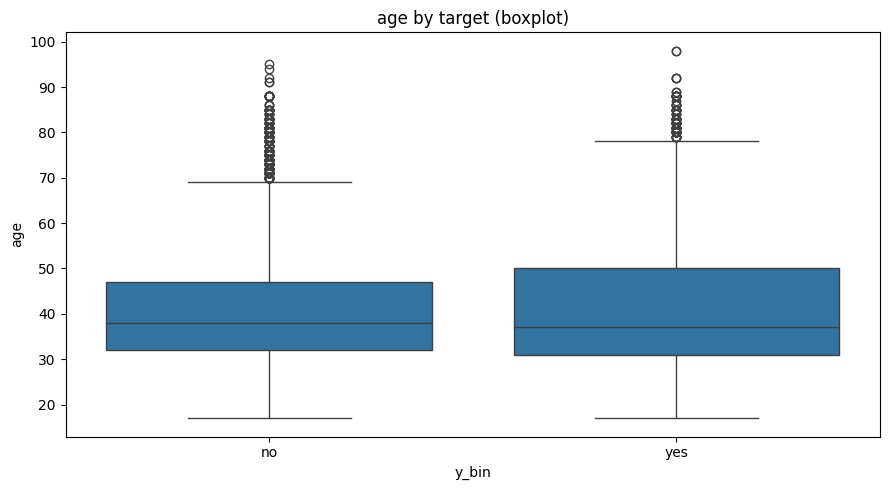

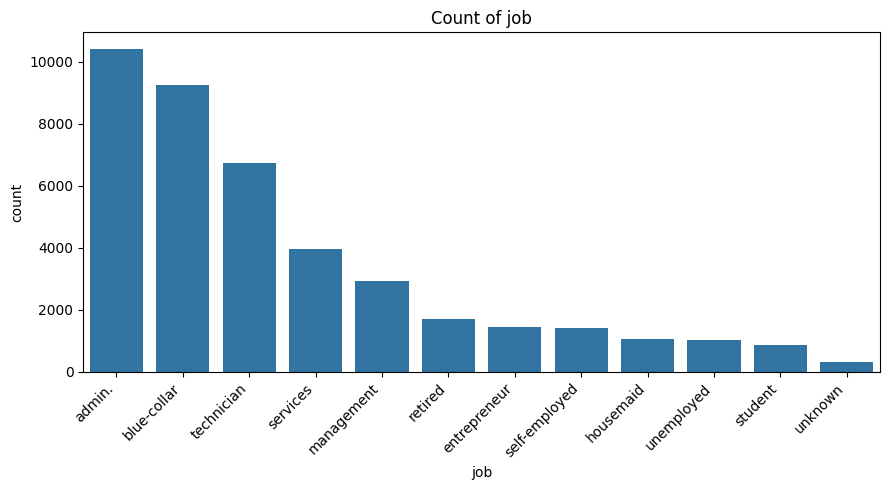

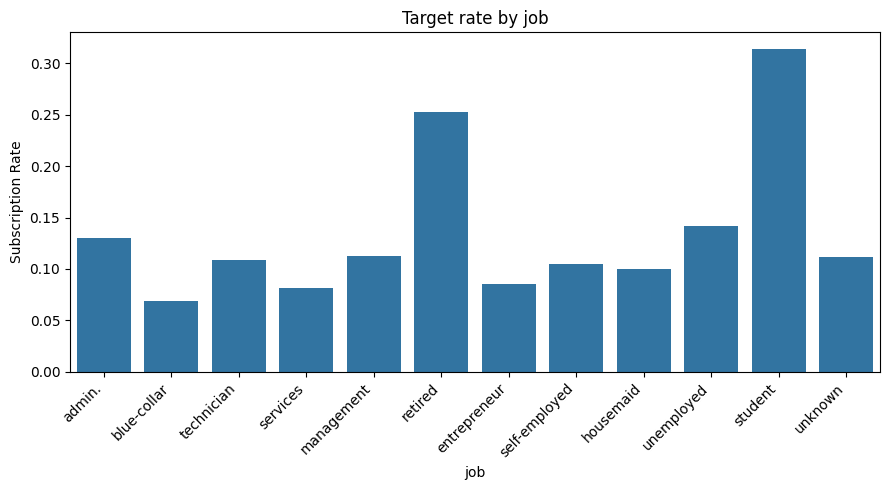

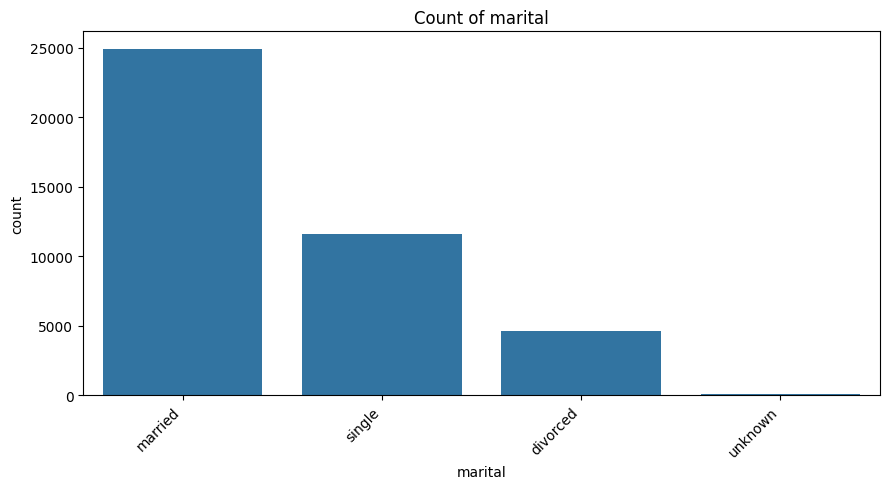

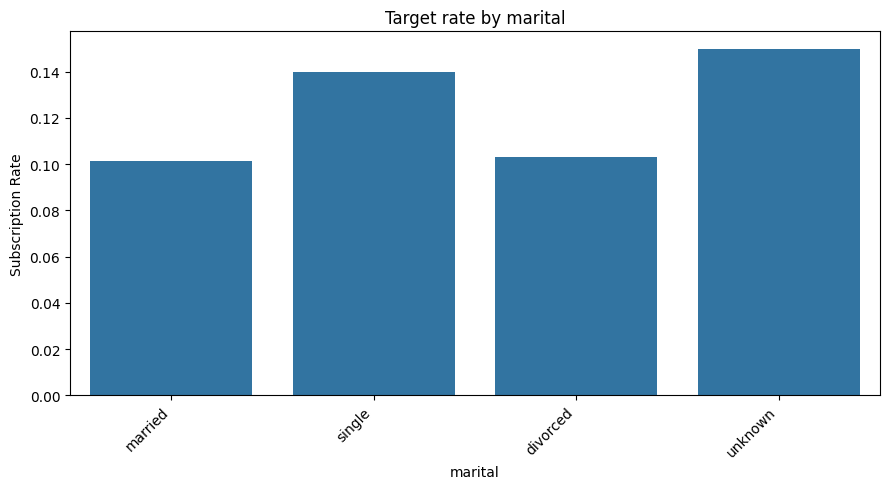

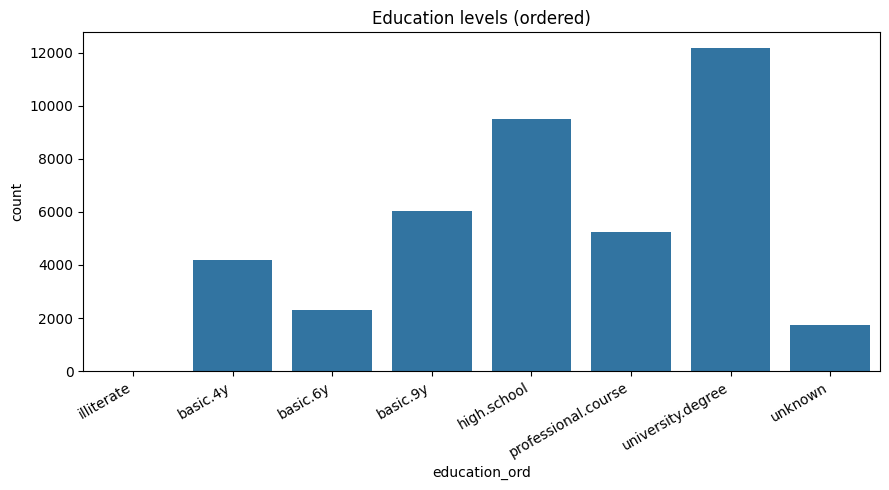

/tmp/ipython-input-4271682225.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = (df.groupby('education_ord', dropna=False)['y_bin']


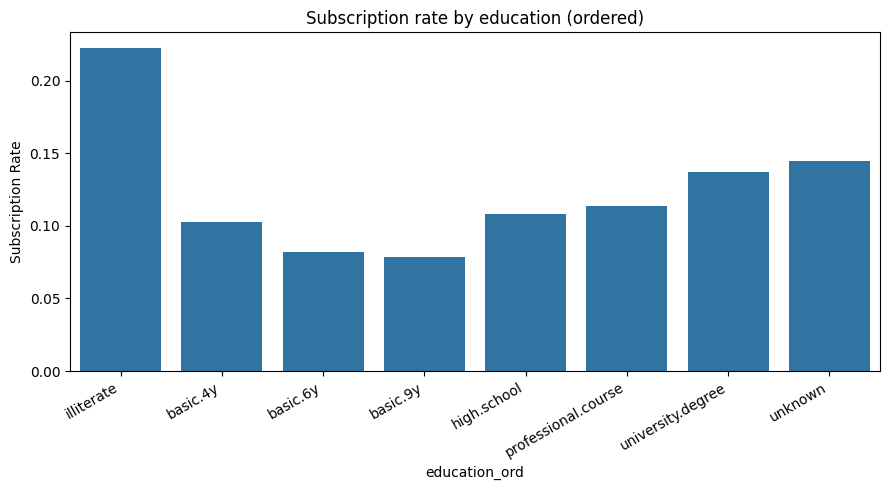

In [ ]:
# age (continuous)
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Distribution of age')
plt.tight_layout(); plt.show()
box_by_target(df, 'age')

# job (categorical)
bar_count(df, 'job')
bar_target_rate(df, 'job', top=12)

# marital (categorical)
bar_count(df, 'marital')
bar_target_rate(df, 'marital')

# education (ordinal categorical – plot in logical order)
# --- Education (ordinal) — FIXED ---
edu_order = [
    'illiterate','basic.4y','basic.6y','basic.9y',
    'high.school','professional.course','university.degree','unknown'
]
df['education_ord'] = pd.Categorical(df['education'], categories=edu_order, ordered=True)

# Count plot in logical order
plt.figure()
sns.countplot(data=df, x='education_ord', order=edu_order)
plt.xticks(rotation=30, ha='right')
plt.title('Education levels (ordered)')
plt.tight_layout(); plt.show()

# Target rate by ordered education (no renaming)
order = edu_order  # preserve the ordinal order
t = (df.groupby('education_ord', dropna=False)['y_bin']
        .agg(n='size', rate='mean')
        .reindex(order)
        .reset_index())

plt.figure()
sns.barplot(data=t, x='education_ord', y='rate', order=order)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Subscription Rate')
plt.title('Subscription rate by education (ordered)')
plt.tight_layout(); plt.show()

df.drop(columns=['education_ord'], inplace=True)



Financial Data

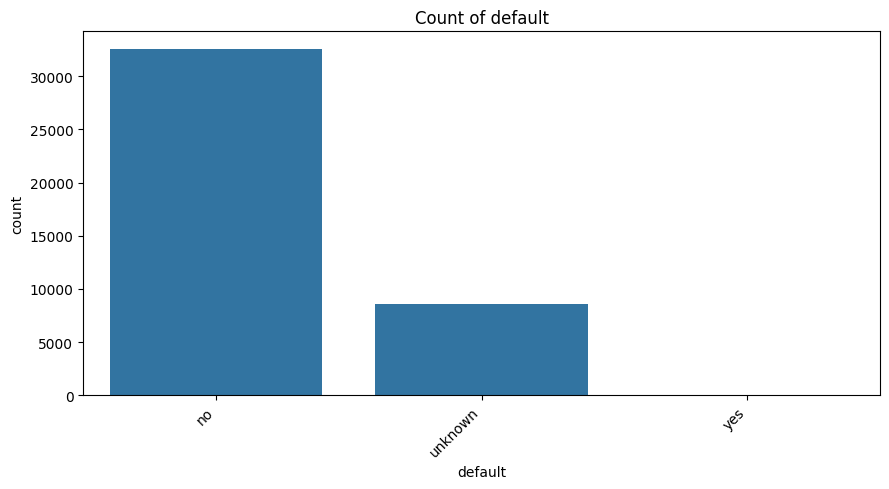

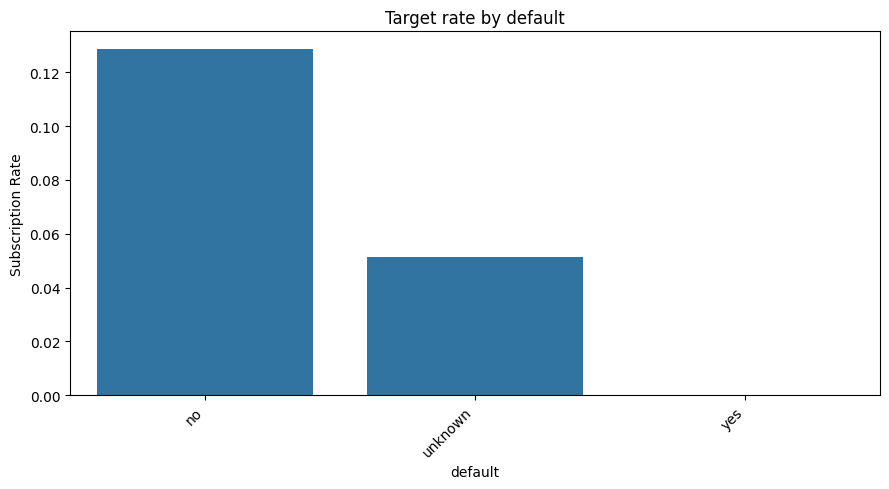

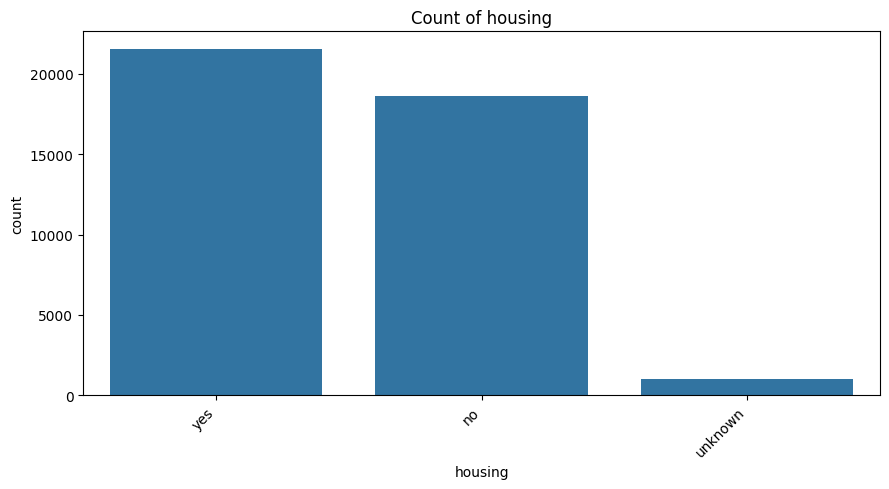

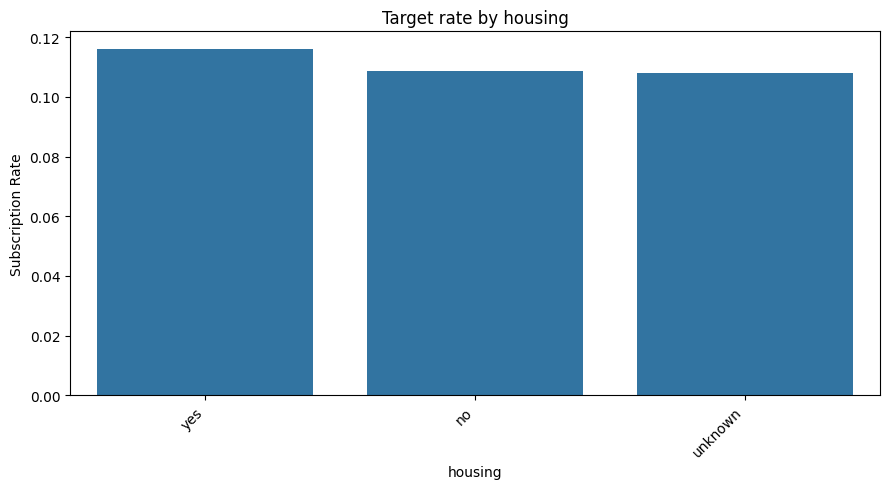

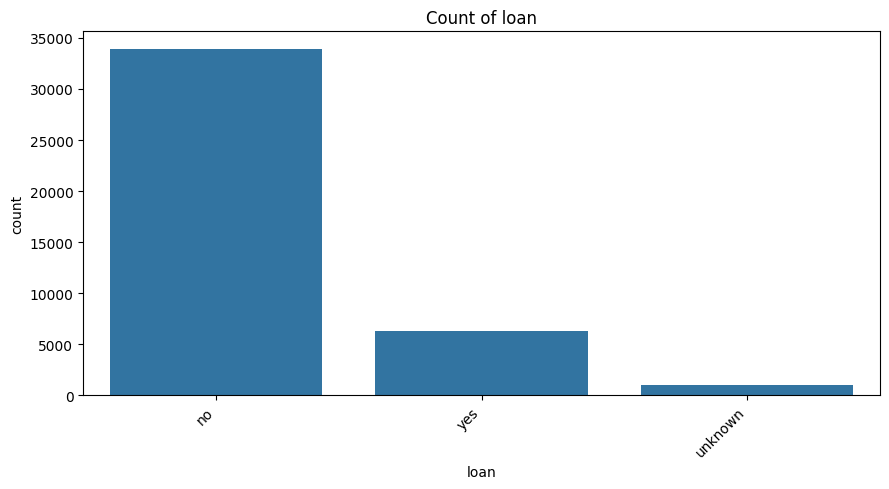

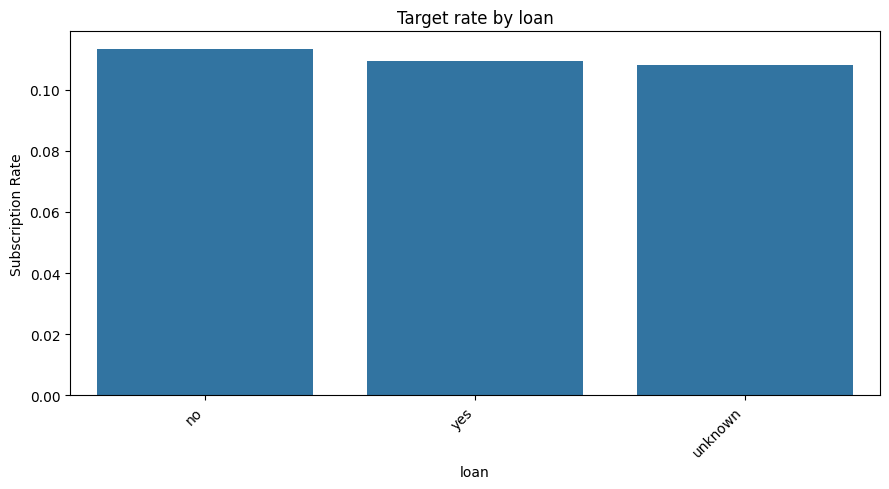

In [ ]:
for c in ['default','housing','loan']:
    bar_count(df, c)
    bar_target_rate(df, c)

Contact and Campaign Data

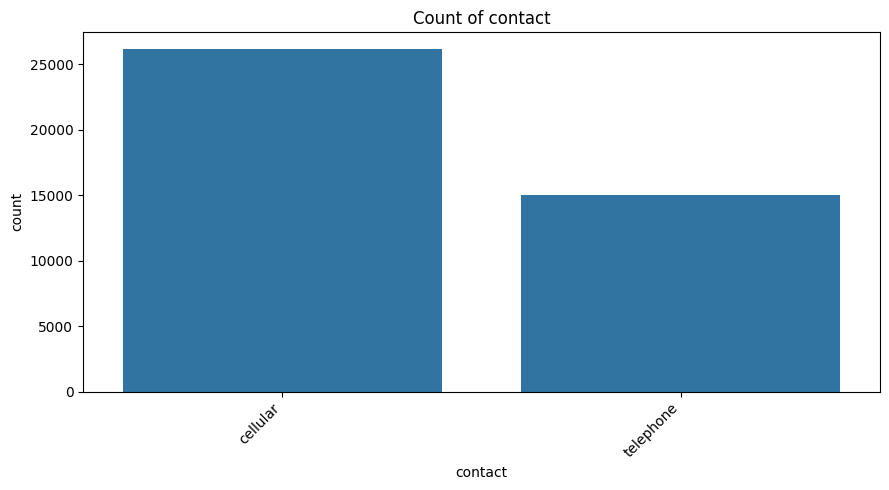

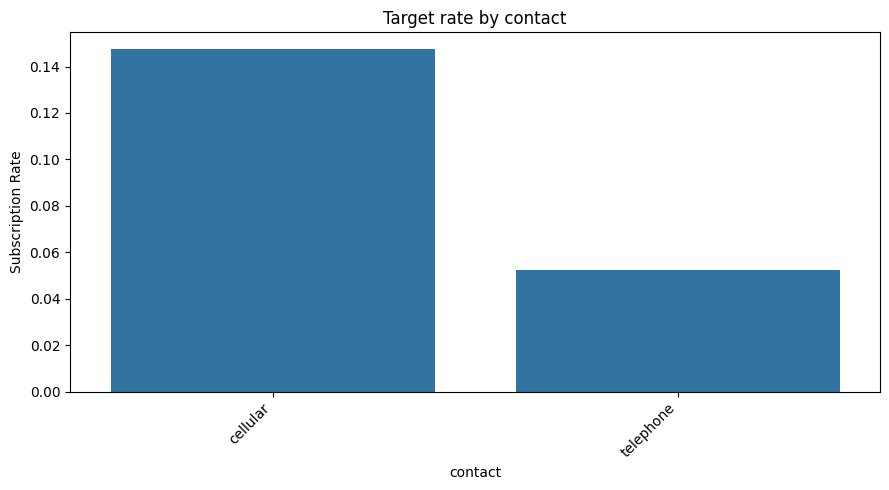

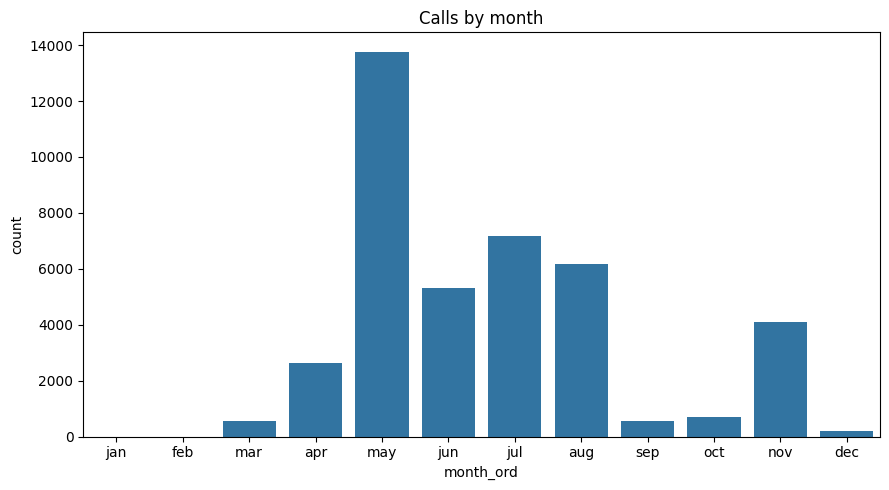

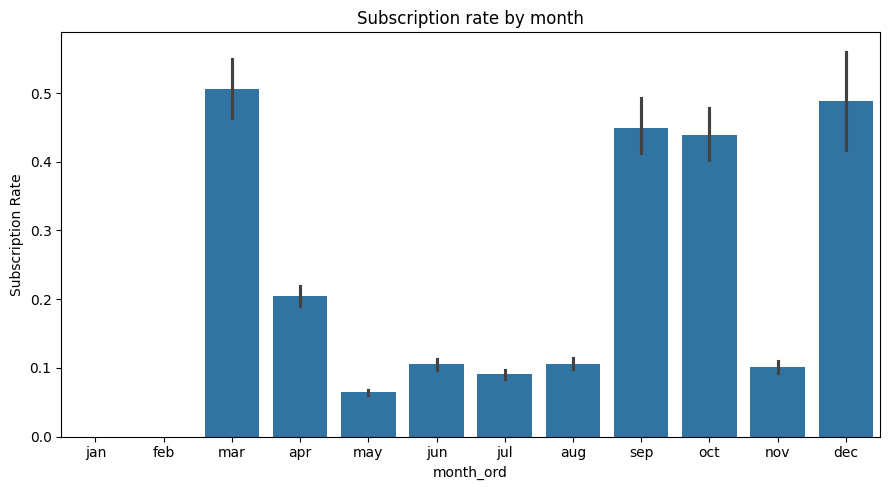

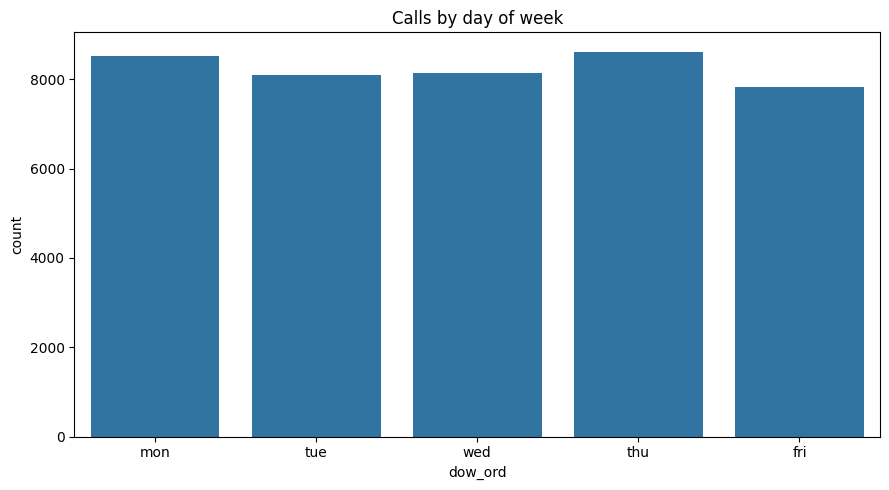

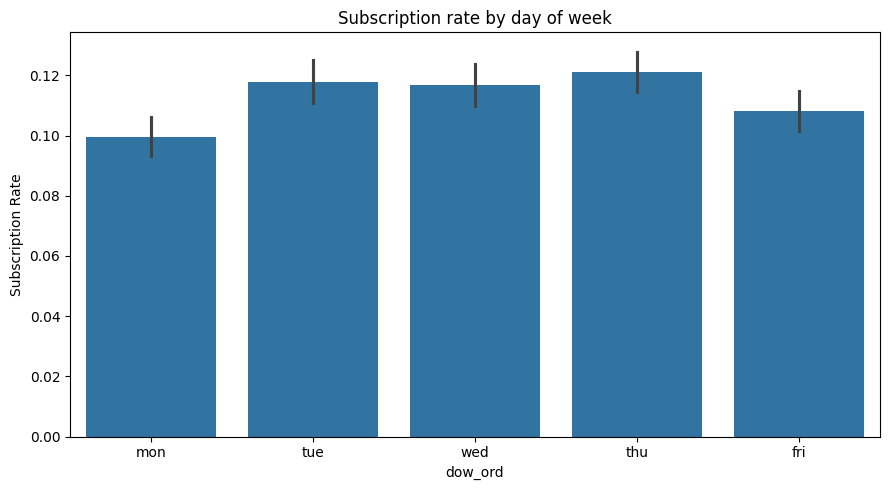

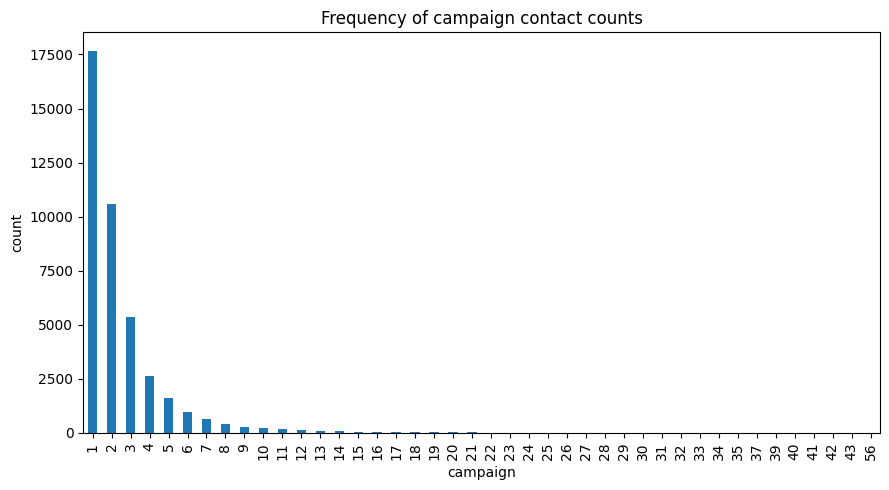

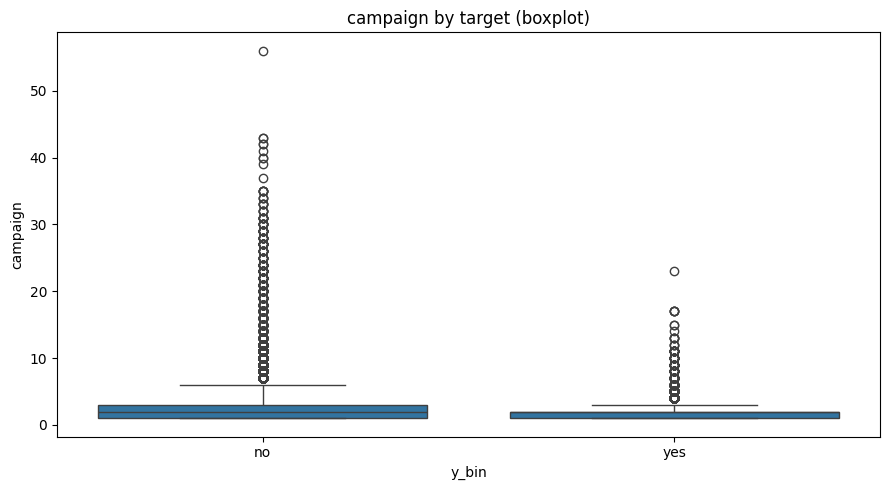

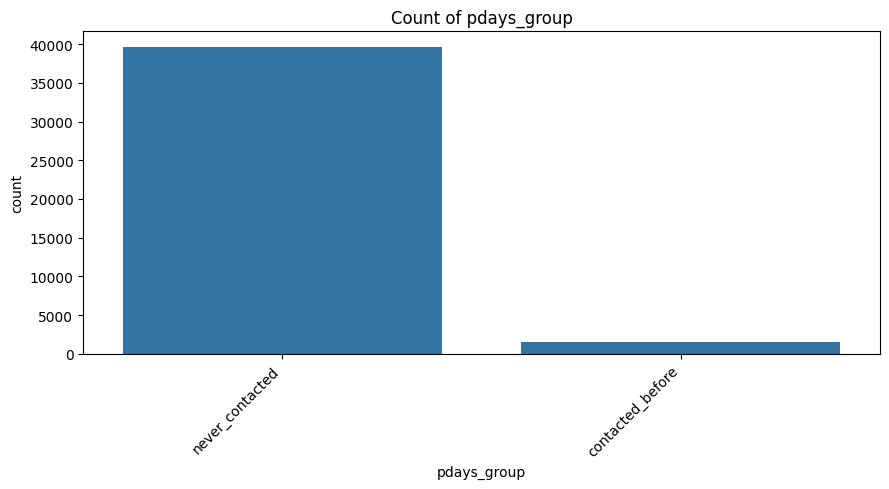

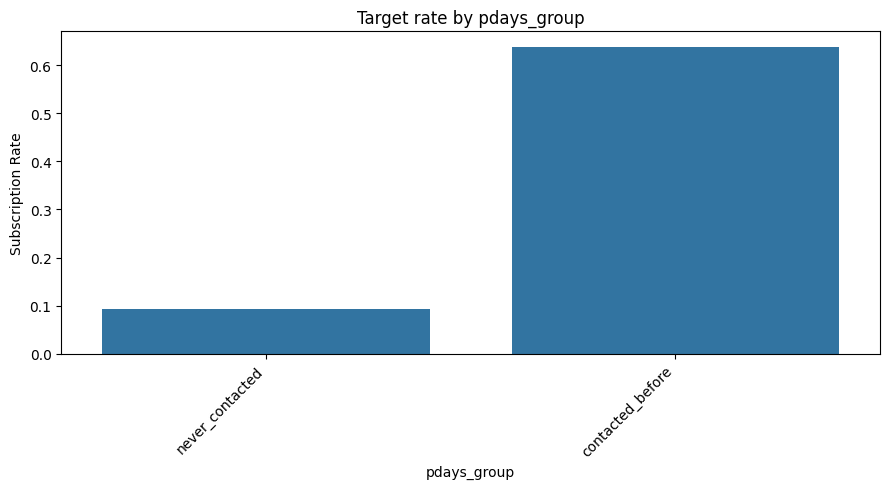

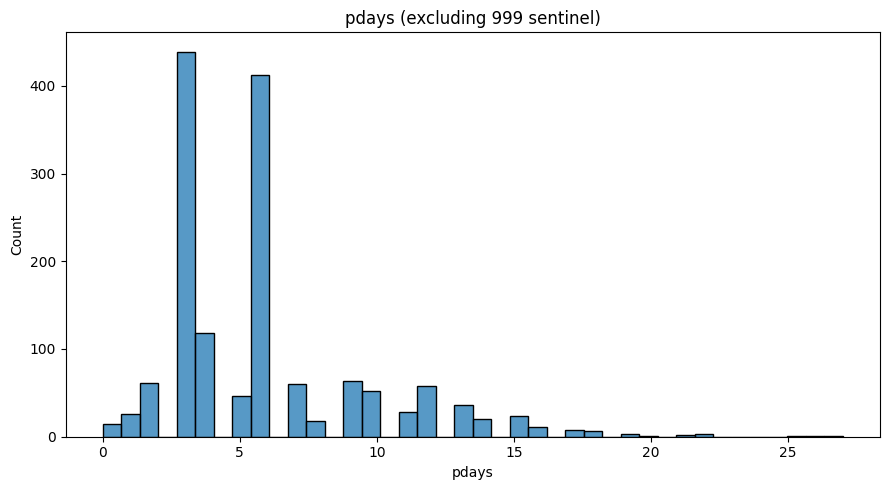

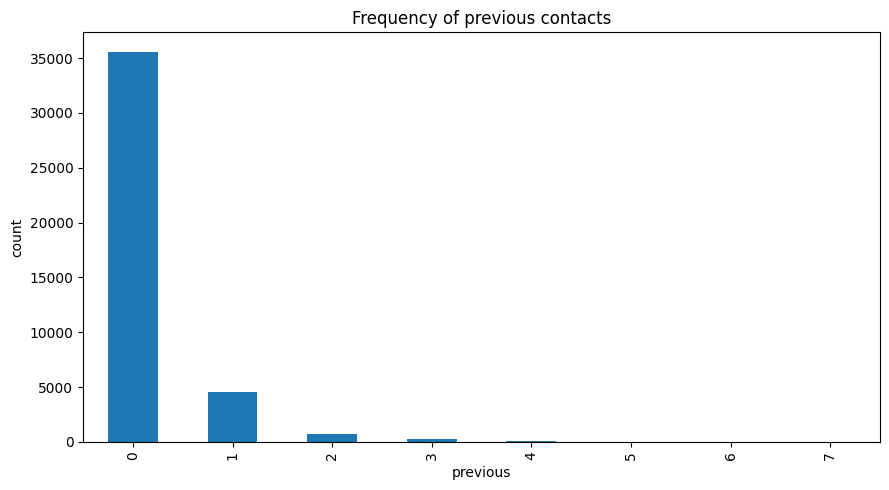

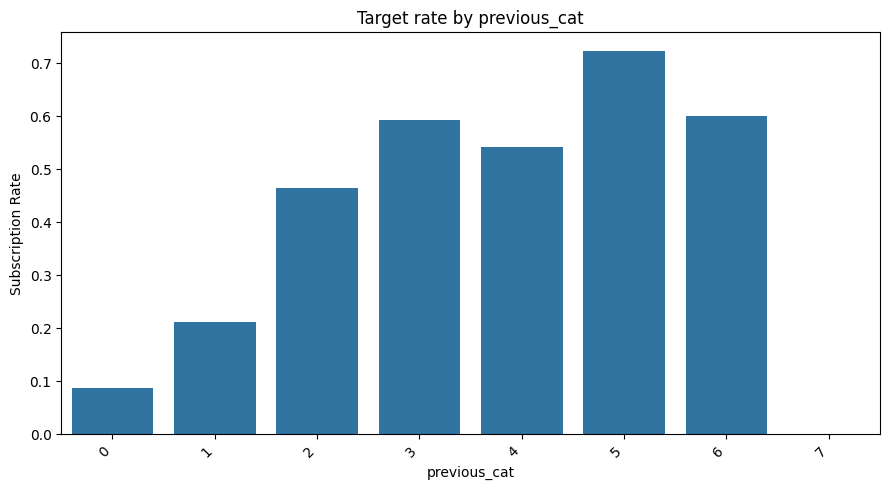

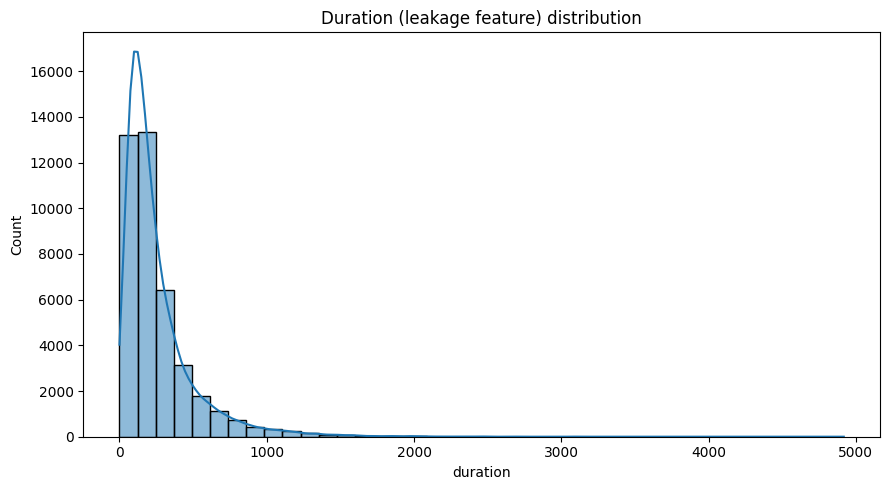

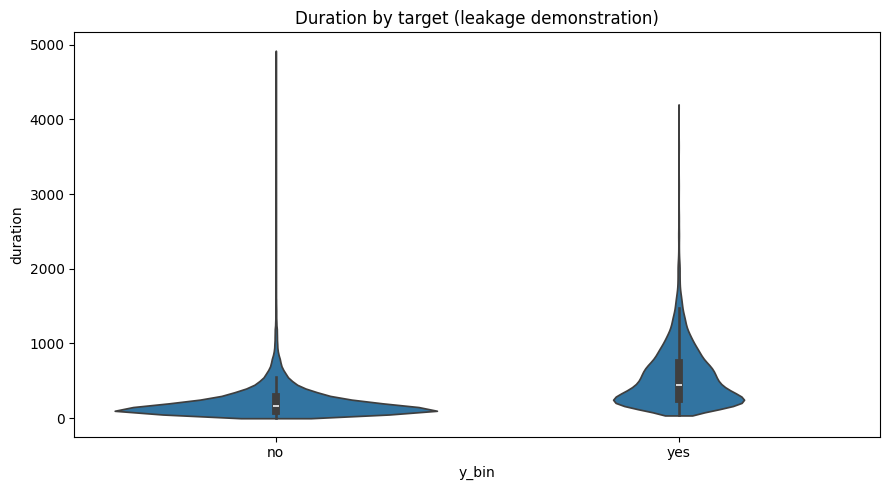

In [ ]:
# contact (categorical)
bar_count(df, 'contact')
bar_target_rate(df, 'contact')

# month (categorical temporal; show in calendar order)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['month_ord'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

plt.figure()
sns.countplot(data=df, x='month_ord')
plt.title('Calls by month'); plt.tight_layout(); plt.show()

plt.figure()
sns.barplot(data=df, x='month_ord', y='y_bin', estimator=np.mean)
plt.ylabel('Subscription Rate'); plt.title('Subscription rate by month')
plt.tight_layout(); plt.show()

df.drop(columns=['month_ord'], inplace=True)

# day_of_week (categorical temporal)
dow_order = ['mon','tue','wed','thu','fri']
df['dow_ord'] = pd.Categorical(df['day_of_week'], categories=dow_order, ordered=True)

plt.figure()
sns.countplot(data=df, x='dow_ord')
plt.title('Calls by day of week'); plt.tight_layout(); plt.show()

plt.figure()
sns.barplot(data=df, x='dow_ord', y='y_bin', estimator=np.mean)
plt.ylabel('Subscription Rate'); plt.title('Subscription rate by day of week')
plt.tight_layout(); plt.show()

df.drop(columns=['dow_ord'], inplace=True)

# campaign (discrete count)
# Frequency of values + target rate by small integer values
vc = df['campaign'].value_counts().sort_index()
plt.figure()
vc.plot(kind='bar')
plt.title('Frequency of campaign contact counts'); plt.xlabel('campaign'); plt.ylabel('count')
plt.tight_layout(); plt.show()
box_by_target(df, 'campaign')

# pdays (999 sentinel = never contacted before)
df['pdays_group'] = np.where(df['pdays'] == 999, 'never_contacted', 'contacted_before')
bar_count(df, 'pdays_group')
bar_target_rate(df, 'pdays_group')
# For contacted_before only, view distribution (log x for spread)
pdays_known = df.loc[df['pdays'] != 999, 'pdays']
if not pdays_known.empty:
    plt.figure()
    sns.histplot(pdays_known, bins=40)
    plt.title('pdays (excluding 999 sentinel)')
    plt.tight_layout(); plt.show()
df.drop(columns=['pdays_group'], inplace=True)

# previous (discrete count)
vc = df['previous'].value_counts().sort_index()
plt.figure()
vc.plot(kind='bar')
plt.title('Frequency of previous contacts'); plt.xlabel('previous'); plt.ylabel('count')
plt.tight_layout(); plt.show()
bar_target_rate(df.assign(previous_cat=df['previous'].astype(str)), 'previous_cat')

# duration (continuous but leakage) – show distribution + by target (flag as leakage)
sns.histplot(df['duration'], bins=40, kde=True)
plt.title('Duration (leakage feature) distribution')
plt.tight_layout(); plt.show()
# Show how it splits the target
plt.figure()
sns.violinplot(data=df, x='y_bin', y='duration', cut=0)
plt.xticks([0,1], ['no','yes'])
plt.title('Duration by target (leakage demonstration)')
plt.tight_layout(); plt.show()


Macroeconomic Data

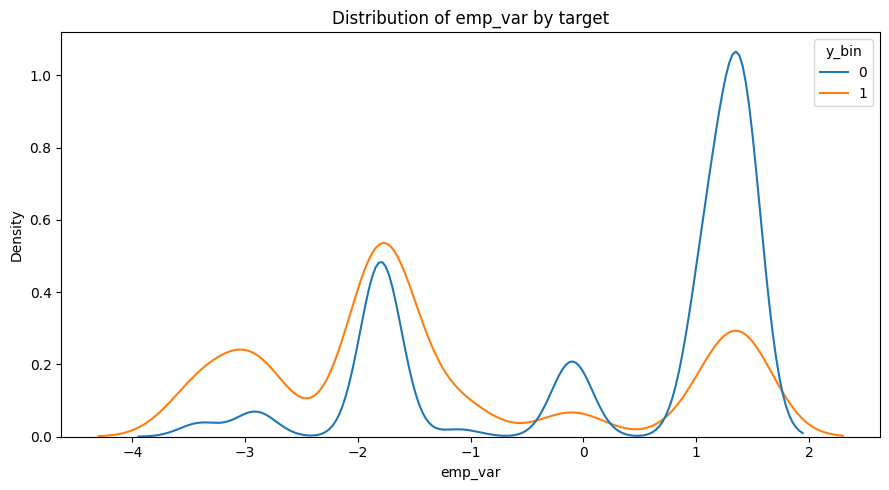

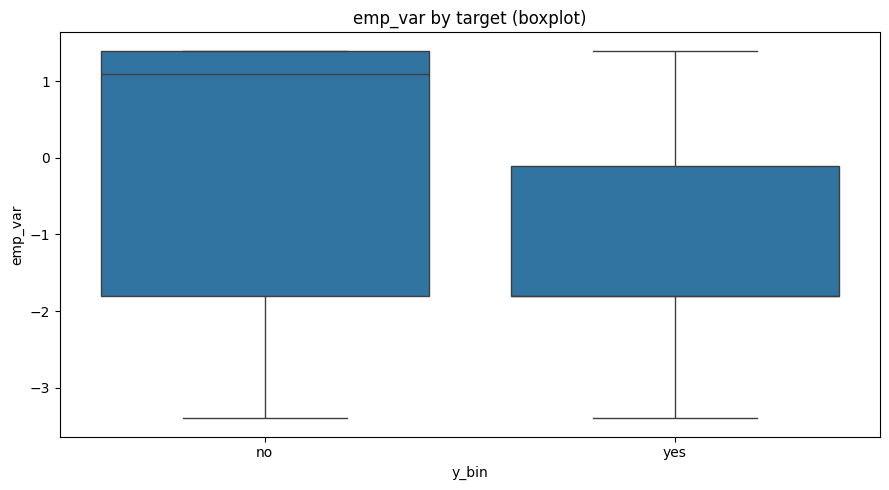

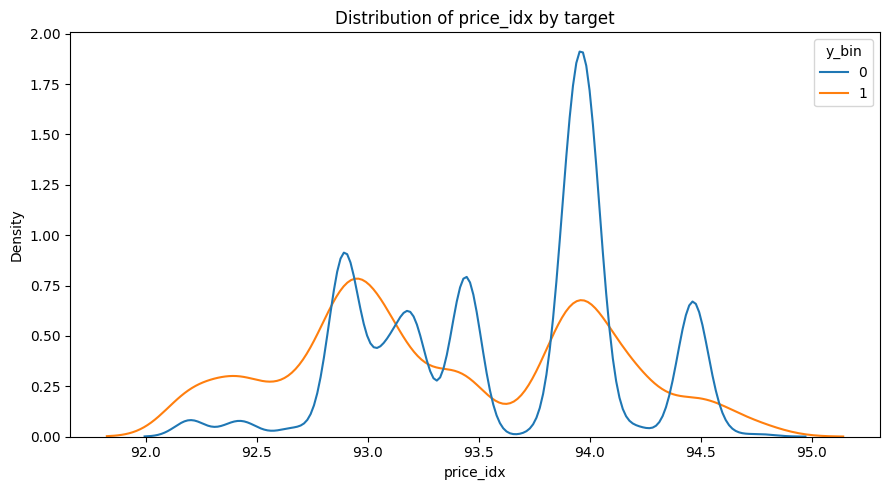

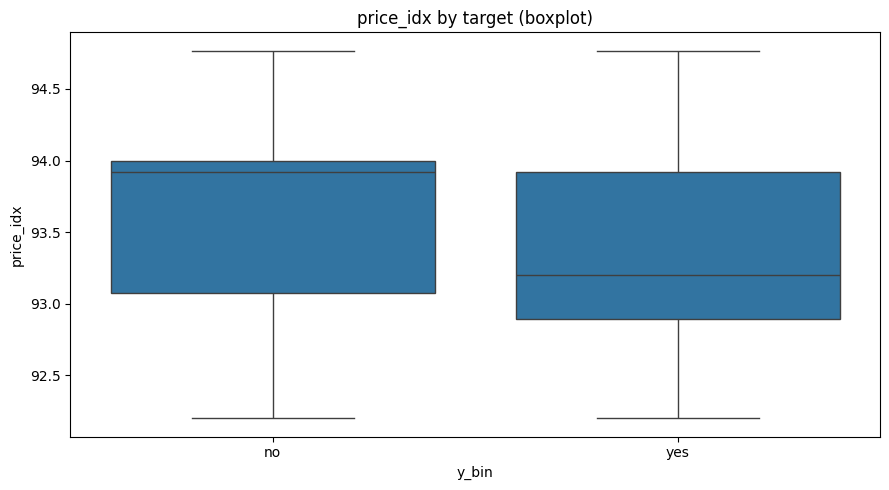

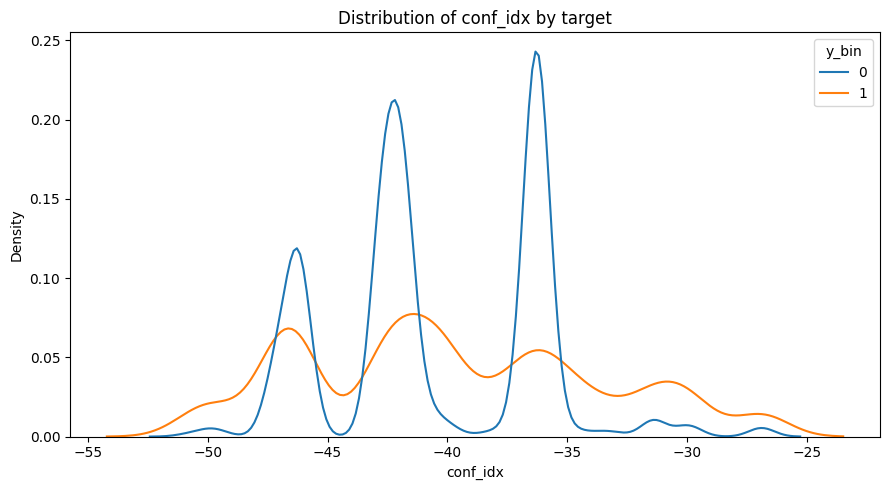

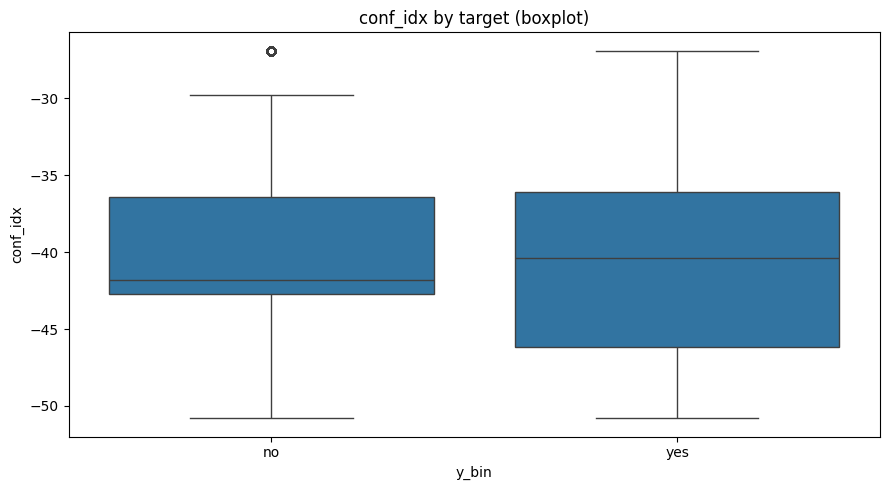

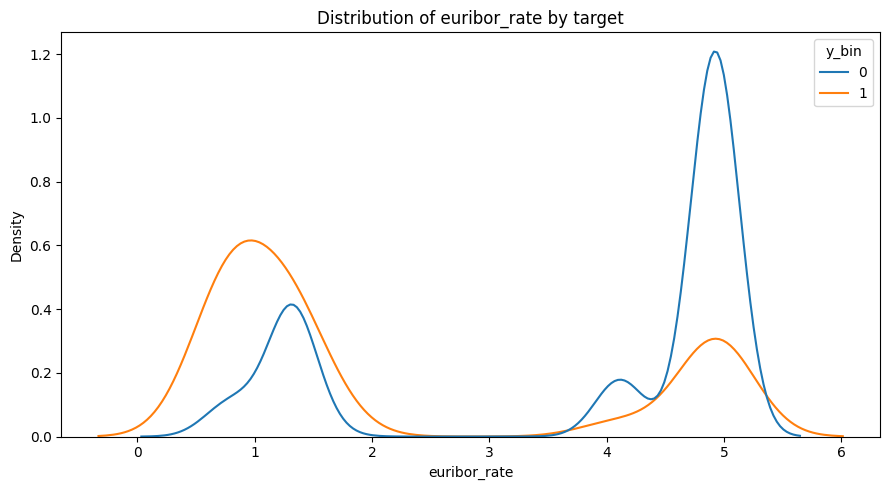

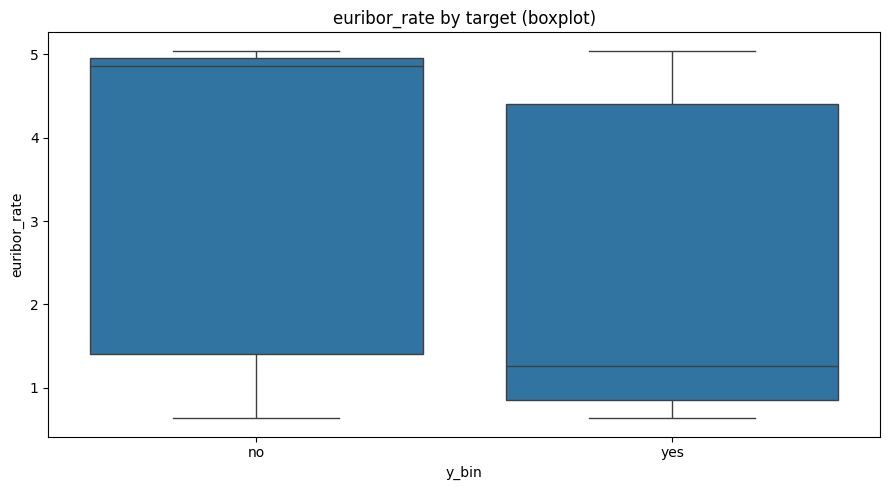

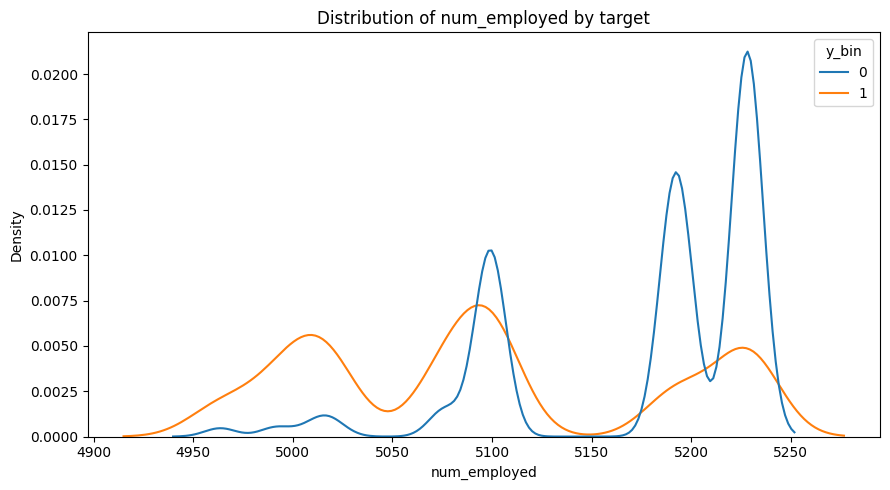

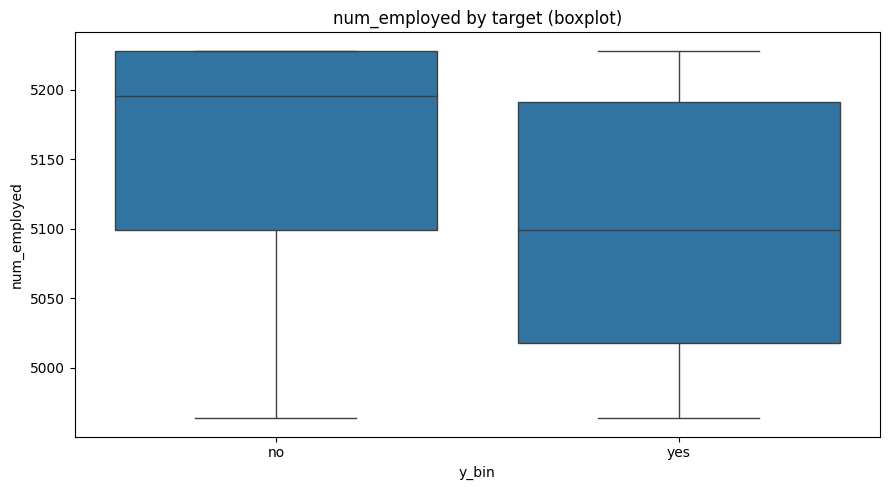

In [ ]:
for c in ['emp_var','price_idx','conf_idx','euribor_rate','num_employed']:
    kde_by_target(df, c)
    box_by_target(df, c)

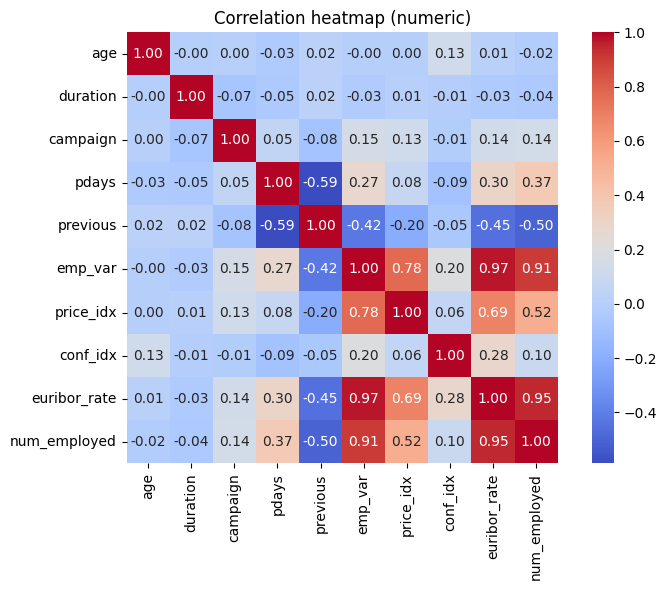

In [ ]:
# ---------- Correlation heatmap (numeric only) ----------
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (numeric)")
plt.tight_layout()
plt.show()

Duration (Excluded in the Model)


Binned target rate vs. duration (illustrates leakage):


/tmp/ipython-input-2479158176.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = tmp.groupby('bin')['y_bin'].mean().reset_index()


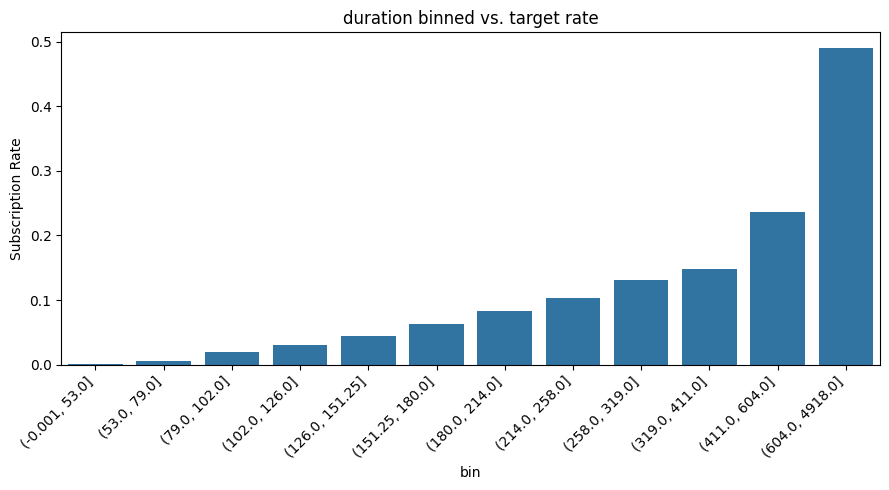

In [ ]:
# ---------- Leakage note on duration ----------
# 'duration' is known post-call; it leaks target information.
# We’ll show its relationship but NOT use it in a realistic model.
def plot_num_vs_target(num_col, k=10):
    tmp = df[[num_col, 'y_bin']].dropna().copy()
    tmp['bin'] = pd.qcut(tmp[num_col], q=k, duplicates='drop')
    grp = tmp.groupby('bin')['y_bin'].mean().reset_index()
    plt.figure()
    sns.barplot(data=grp, x='bin', y='y_bin')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Subscription Rate')
    plt.title(f"{num_col} binned vs. target rate")
    plt.tight_layout()
    plt.show()

print("\nBinned target rate vs. duration (illustrates leakage):")
plot_num_vs_target('duration', k=12)

Exploring initial entropy of features

In [ ]:
# ---------- Simple IV/WoE ----------
def woe_iv_cat(col, y='y_bin', min_count=50):
    t = (df.groupby(col)[y]
           .agg(['count','sum'])
           .rename(columns={'count':'n','sum':'good'})
           .assign(bad=lambda x: x['n'] - x['good'])
           .query("n >= @min_count")
        )
    eps = 0.5  # smoothing to avoid div-by-zero
    t['dist_good'] = (t['good'] + eps) / (t['good'].sum() + eps*len(t))
    t['dist_bad']  = (t['bad']  + eps) / (t['bad'].sum()  + eps*len(t))
    t['woe'] = np.log(t['dist_good'] / t['dist_bad'])
    t['iv'] = (t['dist_good'] - t['dist_bad']) * t['woe']
    return t.sort_values('iv', ascending=False), t['iv'].sum()

print("\nApprox. Information Value (IV) for categoricals (>=50 support):")
iv_scores = []
for c in cat_cols:
    tbl, iv = woe_iv_cat(c)
    iv_scores.append((c, iv))
iv_df = pd.DataFrame(iv_scores, columns=['feature','IV']).sort_values('IV', ascending=False)
display(iv_df)


Approx. Information Value (IV) for categoricals (>=50 support):


,feature,IV
9,poutcome,0.547700
7,month,0.485411
6,contact,0.251477
0,job,0.188627
3,default,0.127572
2,education,0.048099
1,marital,0.028268
8,day_of_week,0.006487
4,housing,0.001373
5,loan,0.000255


Outliers

In [ ]:
# ---------- Outlier scan (IQR rule) ----------
def iqr_outlier_share(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return ((series < lo) | (series > hi)).mean()

outlier_report = pd.Series({c: iqr_outlier_share(df[c].dropna()) for c in numeric_cols}, name='outlier_share')
print("\nOutlier shares (IQR rule):")
display(outlier_report.sort_values(ascending=False).to_frame().style.format({'outlier_share':'{:.2%}'}))


Outlier shares (IQR rule):


,outlier_share
previous,13.66%
duration,7.19%
campaign,5.84%
pdays,3.68%
age,1.14%
conf_idx,1.09%
emp_var,0.00%
price_idx,0.00%
euribor_rate,0.00%
num_employed,0.00%


Multicollinearity

In [ ]:
# ---------- Multicollinearity (VIF) on numeric (excluding duration) ----------

# Numeric features excluding the leakage variable 'duration'
safe_numeric = [c for c in numeric_cols if c != 'duration']

vif_df = df[safe_numeric].copy().dropna()
# Guard against any non-varying columns
vif_df = vif_df.loc[:, vif_df.nunique() > 1]

X = sm.add_constant(vif_df, has_constant='add')
vif_list = []
for i, col in enumerate(X.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(X.values, i)
    vif_list.append((col, vif))
vif_out = pd.DataFrame(vif_list, columns=['feature','VIF']).sort_values('VIF', ascending=False)
print("\nVIF (numeric, excluding duration):")
display(vif_out)


VIF (numeric, excluding duration):


,feature,VIF
7,euribor_rate,64.342881
4,emp_var,33.070180
8,num_employed,31.662087
5,price_idx,6.337933
6,conf_idx,2.648960
3,previous,1.795642
2,pdays,1.612602
1,campaign,1.033689
0,age,1.018878


Finding the difference between initial classification with and without duration

In [ ]:
# ---------- Quick baseline AUCs (sanity check; label-encoding cats) ----------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

def quick_auc(features):
    sub = df.dropna(subset=features + ['y_bin']).copy()
    X = sub[features].copy()
    y = sub['y_bin'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    return roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

# Numerical-only (no duration)
auc_num = quick_auc([c for c in safe_numeric])
print(f"\nAUC (numeric, no duration): {auc_num:.3f}")

# Add duration (to illustrate leakage power)
auc_num_dur = quick_auc([*safe_numeric, 'duration'])
print(f"AUC (+duration; NOT for real modeling): {auc_num_dur:.3f}")



AUC (numeric, no duration): 0.775
AUC (+duration; NOT for real modeling): 0.931


**Data Preparation**

Creating Column Bins

In [ ]:
# Categorical (nominal)
cat_nominal = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

# Ordinal (ordered categories)
cat_ordinal = ['education']

# Numeric
num_features = [
    'age', 'campaign', 'pdays', 'previous',
    'emp_var', 'price_idx', 'conf_idx',
    'euribor_rate', 'num_employed'
]


Addressing Variables with High Multicollinearity

In [ ]:
logit_num_features = num_features.copy()
logit_num_features.remove('euribor_rate')
logit_num_features.remove('emp_var')

# Numeric features excluding the leakage variable 'duration'
logit_safe_numeric = [c for c in logit_num_features if c != 'duration']

vif_df = df[logit_safe_numeric].copy().dropna()
# Guard against any non-varying columns
vif_df = vif_df.loc[:, vif_df.nunique() > 1]

X = sm.add_constant(vif_df, has_constant='add')
vif_list = []
for i, col in enumerate(X.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(X.values, i)
    vif_list.append((col, vif))
vif_out = pd.DataFrame(vif_list, columns=['feature','VIF']).sort_values('VIF', ascending=False)
print("\nVIF (numeric, excluding duration):")
display(vif_out)


VIF (numeric, excluding duration):


,feature,VIF
6,num_employed,1.845401
3,previous,1.791443
2,pdays,1.612328
4,price_idx,1.410502
5,conf_idx,1.056123
1,campaign,1.026364
0,age,1.018556


Feature Engineering

Preprocessing and Train-Test Split

In [ ]:
# Split features and target
X = df.drop(columns=['y','duration', 'y_bin'])
y = df['y']
y = y.map({'no':0, 'yes':1}).astype(int)

# Define encoders
ordinal_enc = OrdinalEncoder(categories=[edu_order])
onehot_enc = OneHotEncoder(handle_unknown='ignore', drop=None)

num_features_logistic = logit_num_features.copy()
cat_nominal_logistic = cat_nominal.copy()
cat_ordinal_logistic = cat_ordinal.copy()

# Define preprocessor
preprocessor = ColumnTransformer([
    ('ord', ordinal_enc, cat_ordinal),
    ('nom', onehot_enc, cat_nominal),
    ('num', StandardScaler(), num_features)
])

preprocessor_logistic = ColumnTransformer([
    ('ord', ordinal_enc, cat_ordinal_logistic),
    ('nom', onehot_enc, cat_nominal_logistic),
    ('num', StandardScaler(), num_features_logistic)
])

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var,price_idx,conf_idx,euribor_rate,num_employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0


Dataset Balancing

In [ ]:
print('Original dataset shape %s' % Counter(y))
print('Train dataset shape %s' % Counter(y_train))
print('Test dataset shape %s' % Counter(y_test))

ros = RandomOverSampler(random_state=42) # default sampling strategy: resample all classes but the majority class
X_oversampled_train, y_oversampled_train = ros.fit_resample(X_train, y_train)

print('Resampled train dataset shape %s' % Counter(y_oversampled_train))

Original dataset shape Counter({0: 36548, 1: 4640})
Train dataset shape Counter({0: 25583, 1: 3248})
Test dataset shape Counter({0: 10965, 1: 1392})
Resampled train dataset shape Counter({0: 25583, 1: 25583})


**Model Processing and Hyperparameter Tuning**

Inital Regressions

In [ ]:
# Logistic Regression Pipeline
logit_pipe = Pipeline([
    ('preprocessor', preprocessor_logistic),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# k-Nearest Neighbors Pipeline
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Decision Tree Pipeline
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

Cross Validation for Generalization Performance

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

models = {
    'Logistic Regression': logit_pipe,
    'k-NN': knn_pipe,
    'Decision Tree': dt_pipe
}

cv_results = {}

for name, model in models.items():
    scores = cross_validate(model, X_oversampled_train, y_oversampled_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {metric: np.mean(values) for metric, values in scores.items() if metric.startswith('test')}


In [ ]:
cv_summary = pd.DataFrame(cv_results).T
cv_summary = cv_summary.rename(columns=lambda x: x.replace('test_', ''))
print(cv_summary.sort_values('f1', ascending=False))

                     accuracy  precision    recall        f1   roc_auc
Decision Tree        0.943322   0.899600  0.998046  0.946266  0.944830
k-NN                 0.872689   0.806369  0.980964  0.885134  0.938631
Logistic Regression  0.736153   0.803019  0.625767  0.703347  0.792434


Nested Cross Validation

In [ ]:
 # Hyperparameter grids
 param_grids = {
     'Logistic Regression': {
         'classifier__C': [0.01,0.1, 1, 10, 100],
         'classifier__penalty': ['l2'],
         'classifier__solver':['lbfgs']
     },
     'k-NN': {
         'classifier__n_neighbors': [3, 7, 11,15],
         'classifier__weights': ['distance','uniform'],
         'classifier__p': [1,2]
     },
     'Decision Tree': {
         'classifier__criterion': ['gini','entropy'],
         'classifier__max_depth': [3, 7, 10, None],
         'classifier__min_samples_split': [2, 4, 8]
     }
}

 inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

 nested_summary_rows = []
 overall_best_params = {}



In [ ]:
# Logistic Regression
inner_grid_logit = GridSearchCV(
         estimator=logit_pipe,
         param_grid=param_grids['Logistic Regression'],
         cv=inner_cv,
         scoring='f1',
         n_jobs=1,
         refit=True
     )
nested_scores_logit = cross_val_score(
         inner_grid_logit, X_oversampled_train, y_oversampled_train,
         cv=outer_cv,
         scoring='f1',
         n_jobs=-1
     )
nested_summary_rows.append({
         'Model': 'Logistic Regression',
         'Mean F1 (Nested CV)': nested_scores_logit.mean(),
         'Std F1 (Nested CV)': nested_scores_logit.std()
     })
inner_grid_logit.fit(X_train, y_train)
overall_best_params['Logistic Regression'] = inner_grid_logit.best_params_
print(inner_grid_logit.best_params_)

{'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


In [ ]:
# Decision Tree
inner_grid_dt = GridSearchCV(
         estimator=dt_pipe,
         param_grid=param_grids['Decision Tree'],
         cv=inner_cv,
         scoring='f1',
         n_jobs=1,
         refit=True
     )
nested_scores_dt = cross_val_score(
         inner_grid_dt, X_oversampled_train, y_oversampled_train,
         cv=outer_cv,
         scoring='f1',
         n_jobs=-1
     )
nested_summary_rows.append({
         'Model': 'Decision Tree',
         'Mean F1 (Nested CV)': nested_scores_dt.mean(),
         'Std F1 (Nested CV)': nested_scores_dt.std()
     })
inner_grid_dt.fit(X_train, y_train)
overall_best_params['Decision Tree'] = inner_grid_dt.best_params_
print(inner_grid_dt.best_params_)

{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 4}


**Evaluation**

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn import neighbors, linear_model,metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, cohen_kappa_score,  confusion_matrix, classification_report, auc,roc_curve
from sklearn.model_selection import train_test_split, KFold, cross_val_score,learning_curve, ShuffleSplit, StratifiedKFold, validation_curve, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

Building Regressions

In [ ]:
logit_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor_logistic),
    ('classifier', LogisticRegression(C= 100,penalty= 'l2',solver= 'lbfgs',max_iter=1000,random_state=42))
])

# k-Nearest Neighbors Pipeline
knn_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=7,weights='uniform',p=1))
])

# Decision Tree Pipeline
dt_pipe_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth= 10,min_samples_split=4,criterion='gini',random_state=42))
])

# logreg = LogisticRegression(C= 100,penalty= 'l2',solver= 'lbfgs',max_iter=1000,random_state=42)
# # 'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'
# knn = KNeighborsClassifier(n_neighbors=3,weights='distance',p=1)

# #- k-NN: {'classifier__n_neighbors': 3, 'classifier__p': 1, 'classifier__weights': 'uniform'}

# dt = DecisionTreeClassifier(max_depth= 10,min_samples_split=4,criterion='gini',random_state=42)
# # {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 4}

In [ ]:
X_tr = X_oversampled_train.copy()
y_tr = y_oversampled_train.copy()

logit_pipe_tuned.fit(X_tr, y_tr)
knn_pipe_tuned.fit(X_tr, y_tr)
dt_pipe_tuned.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ord',
                                                  OrdinalEncoder(categories=[['illiterate',
                                                                              'basic.4y',
                                                                              'basic.6y',
                                                                              'basic.9y',
                                                                              'high.school',
                                                                              'professional.course',
                                                                              'university.degree',
                                                                              'unknown']]),
                                                  ['education']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp_var',
                                                   'price_idx', 'conf_idx',
                                                   'euribor_rate',
                                                   'num_employed'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=10, min_samples_split=4,
                                        random_state=42))])

In [ ]:
X_te = X_test.copy()
y_te = y_test.copy()

y_pred_logreg = logit_pipe_tuned.predict(X_te)
y_pred_knn    = knn_pipe_tuned.predict(X_te)
y_pred_dt     = dt_pipe_tuned.predict(X_te)

# Probabilities (for ROC/AUC)
y_proba_logreg = logit_pipe_tuned.predict_proba(X_te)[:, 1]
y_proba_knn    = knn_pipe_tuned.predict_proba(X_te)[:, 1]
y_proba_dt     = dt_pipe_tuned.predict_proba(X_te)[:, 1]

In [ ]:
models = [
    ("Logistic Regression", y_pred_logreg, y_proba_logreg),
    ("k-NN",                y_pred_knn,    y_proba_knn),
    ("Decision Tree",       y_pred_dt,     y_proba_dt)
]

for name, y_pred, y_proba in models:
    print(f"\n=== {name} (Out-of-Sample) ===")
    print("Accuracy : %.3f"  % accuracy_score(y_te, y_pred))
    print("Precision: %.3f"  % precision_score(y_te, y_pred, pos_label=1))
    print("Recall   : %.3f"  % recall_score(y_te, y_pred, pos_label=1))
    print("F1-score : %.3f"  % f1_score(y_te, y_pred, pos_label=1))
    print("AUC-ROC  : %.3f"  % roc_auc_score((y_te==1).astype(int), y_proba))

    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))


=== Logistic Regression (Out-of-Sample) ===
Accuracy : 0.826
Precision: 0.352
Recall   : 0.647
F1-score : 0.455
AUC-ROC  : 0.802

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     10965
           1       0.35      0.65      0.46      1392

    accuracy                           0.83     12357
   macro avg       0.65      0.75      0.68     12357
weighted avg       0.88      0.83      0.85     12357


=== k-NN (Out-of-Sample) ===
Accuracy : 0.736
Precision: 0.241
Recall   : 0.624
F1-score : 0.347
AUC-ROC  : 0.721

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.75      0.83     10965
           1       0.24      0.62      0.35      1392

    accuracy                           0.74     12357
   macro avg       0.59      0.69      0.59     12357
weighted avg       0.86      0.74      0.78     12357


=== Decision Tree (Out-of-Sample) ===
Accuracy : 0.8

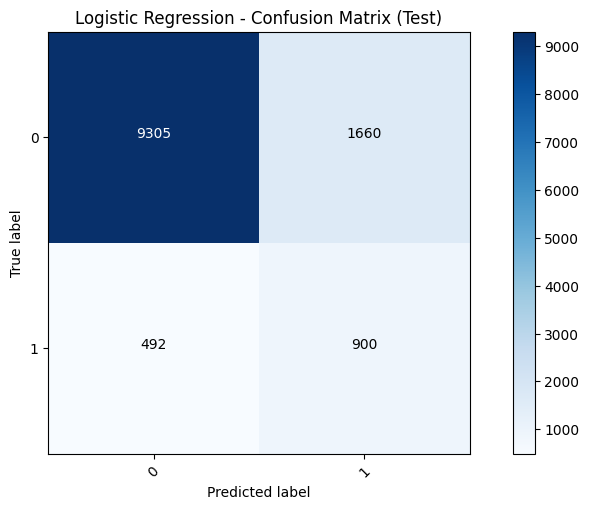

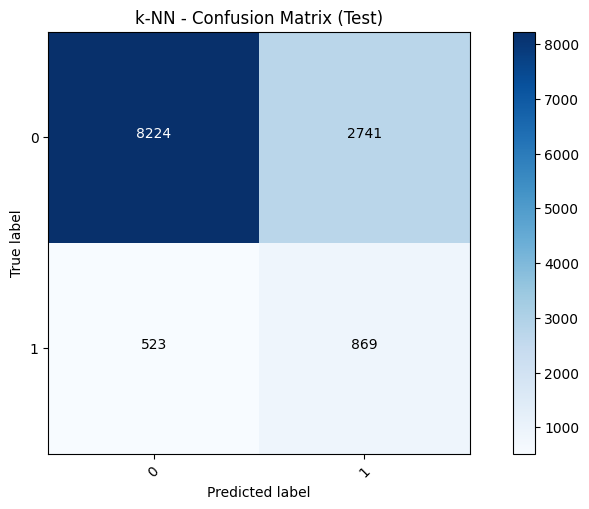

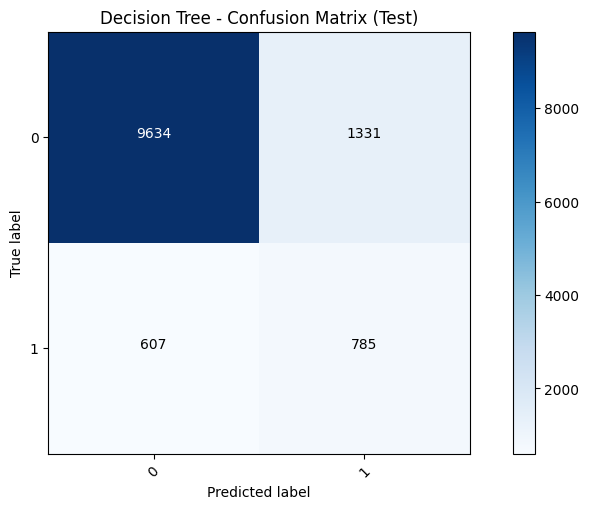

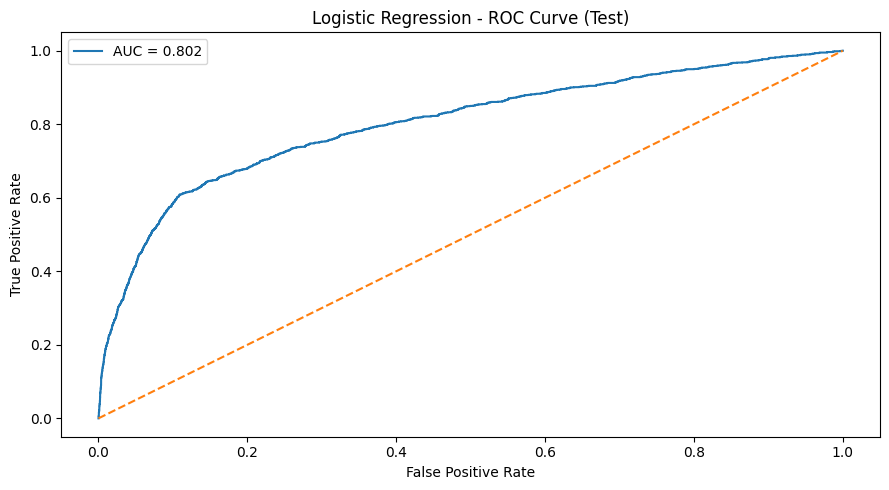

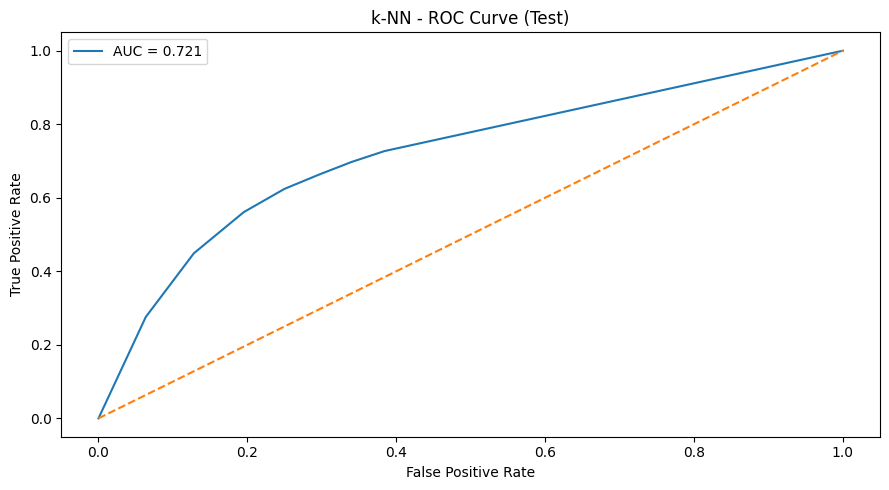

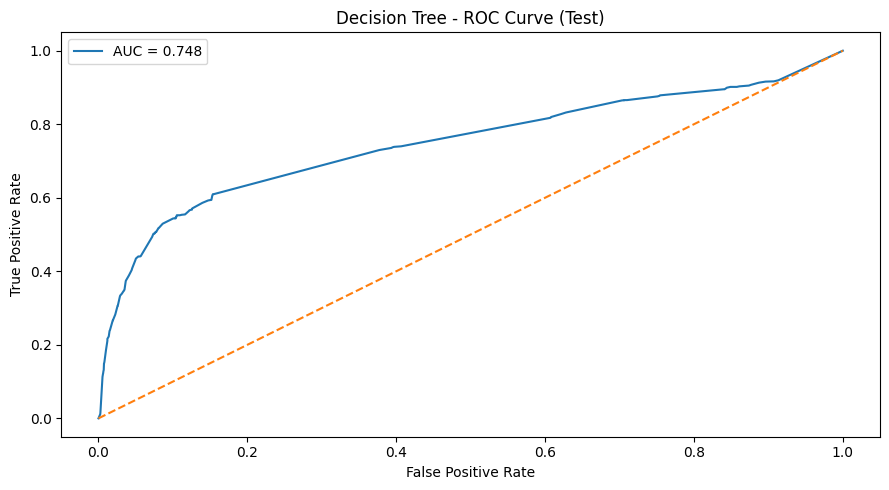

In [ ]:
def plot_confusion_matrix(cm, classes=(0,1), title="Confusion matrix"):
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# --- Confusion Matrices ---
for name, y_pred, _ in models:
    cm = confusion_matrix(y_te, y_pred, labels=[0,1])
    plt.figure()
    plot_confusion_matrix(cm, classes=(0,1), title=f"{name} - Confusion Matrix (Test)")
    plt.show()

# --- ROC Curves ---
for name, _, y_proba in models:
    fpr, tpr, _ = roc_curve((y_te==1).astype(int), y_proba)
    auc = roc_auc_score((y_te==1).astype(int), y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve (Test)")
    plt.legend()
    plt.tight_layout()
    plt.show()

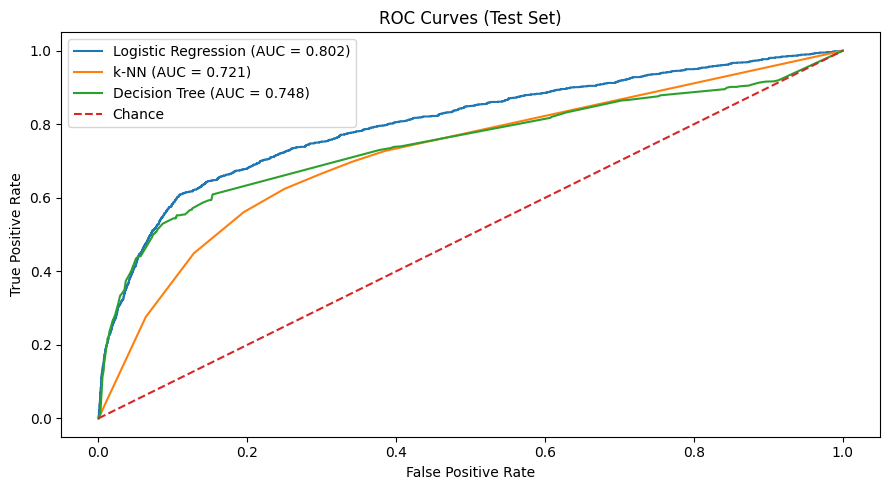

In [ ]:
plt.figure()
for name, _, y_proba in models:
    fpr, tpr, _ = roc_curve((y_te==1).astype(int), y_proba)
    auc = roc_auc_score((y_te==1).astype(int), y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],"--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

Learning Curve


In [ ]:
### Function for Learning Curves
def plot_learning_curve(estimator, title, X, y, scoring_method, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 10)):
    plt.figure()                    #display figure
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples") #y label title
    plt.ylabel(scoring_method)             #x label title

    # Class learning_curve determines cross-validated training and test scores for different training set sizes
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, scoring = scoring_method, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,random_state =42)

    # Cross validation statistics for training and testing data (mean and standard deviation)
    train_scores_mean = np.mean(train_scores, axis=1) # Compute the arithmetic mean along the specified axis.
    train_scores_std = np.std(train_scores, axis=1)   # Compute the standard deviation along the specified axis.
    test_scores_mean = np.mean(test_scores, axis=1)   # Compute the arithmetic mean along the specified axis.
    test_scores_std = np.std(test_scores, axis=1)     # Compute the standard deviation along the specified axis.

    plt.grid() # Configure the grid lines

    # Fill the area around the line to indicate the size of standard deviations for the training data
    # and the test data
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r") # train data performance indicated with red
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g") # test data performance indicated with green

    # Cross-validation means indicated by dots
    # Train data performance indicated with red
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    # Test data performance indicated with green
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best") # Show legend of the plot at the best location possible
    return plt             # Function that returns the plot as an output

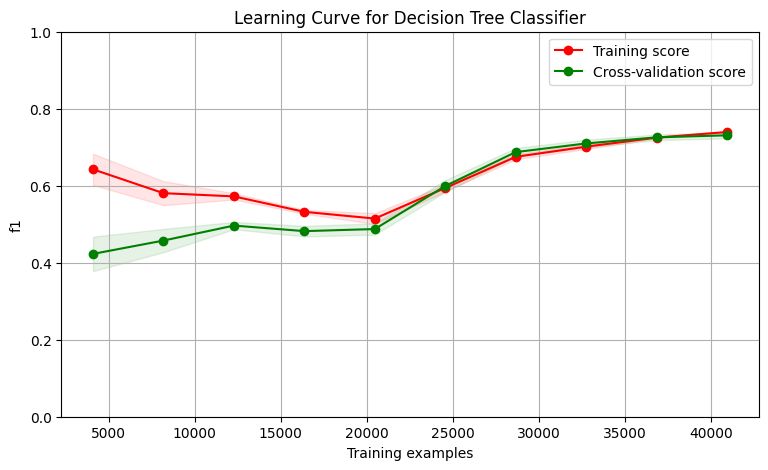

In [ ]:
# Learning Curve: Decision Tree
plot_learning_curve(dt_pipe_tuned, "Learning Curve for Decision Tree Classifier", X_oversampled_train, y_oversampled_train, 'f1',(0.0, 1.0), cv=cv, n_jobs=4)
plt.show()

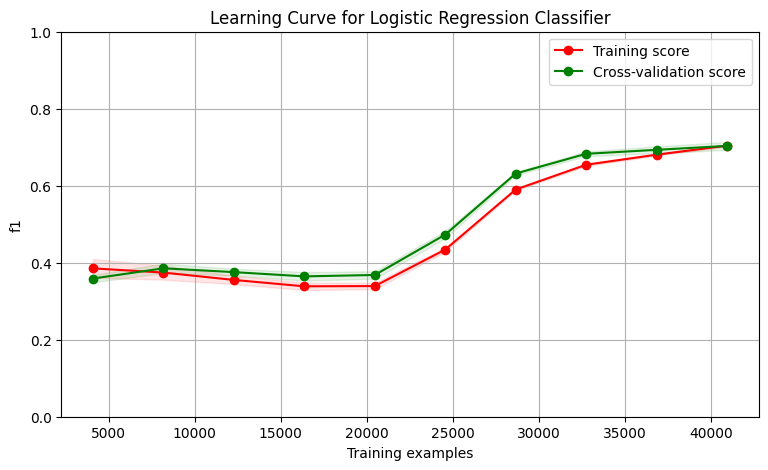

In [ ]:
# Learning Curve: Logistic Regression Classifier
plot_learning_curve(logit_pipe_tuned, "Learning Curve for Logistic Regression Classifier", X_oversampled_train, y_oversampled_train, 'f1',(0.0, 1.0), cv=cv, n_jobs=4)
plt.show()

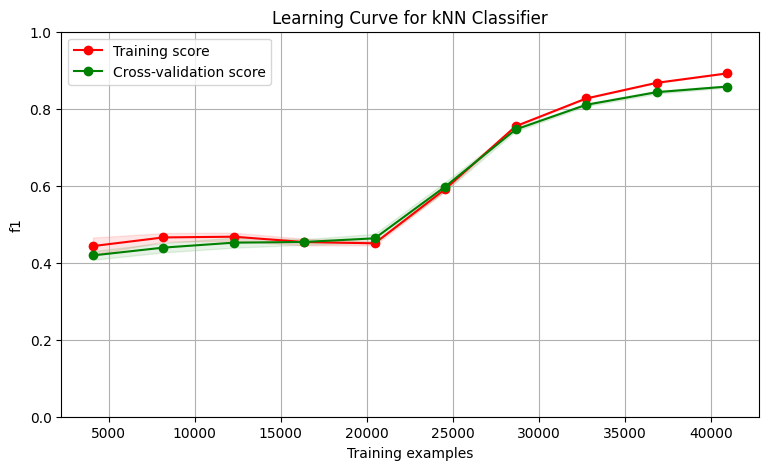

In [ ]:
# Learning Curve: kNN Classifier
plot_learning_curve(knn_pipe_tuned, "Learning Curve for kNN Classifier", X_oversampled_train, y_oversampled_train, 'f1',(0.00, 1.0), cv=cv, n_jobs=4)
plt.show()

Fitting Graph

In [ ]:
# Function for fitting graphs
def plot_fitting_curve(estimator, title, X, y,param_name,param_range,scoring_method, ylim=None, cv=None,
                        n_jobs=1):

    plt.figure()
    plt.grid()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Parameter "+param_name)
    plt.ylabel(scoring_method)

    train_scores, test_scores = validation_curve(estimator=estimator, X=X,y=y,param_name=param_name, param_range=param_range,cv=cv,scoring=scoring_method,n_jobs=4)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.plot(param_range, train_mean, color='blue', marker='o',markersize=5, label='training f1-score')
    plt.fill_between(param_range, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

    plt.plot(param_range, test_mean,color='green', linestyle='--', marker='s', markersize=5, label='validation f1-score')
    plt.fill_between(param_range,test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

    plt.legend(loc='best')
    plt.tight_layout()
    return plt

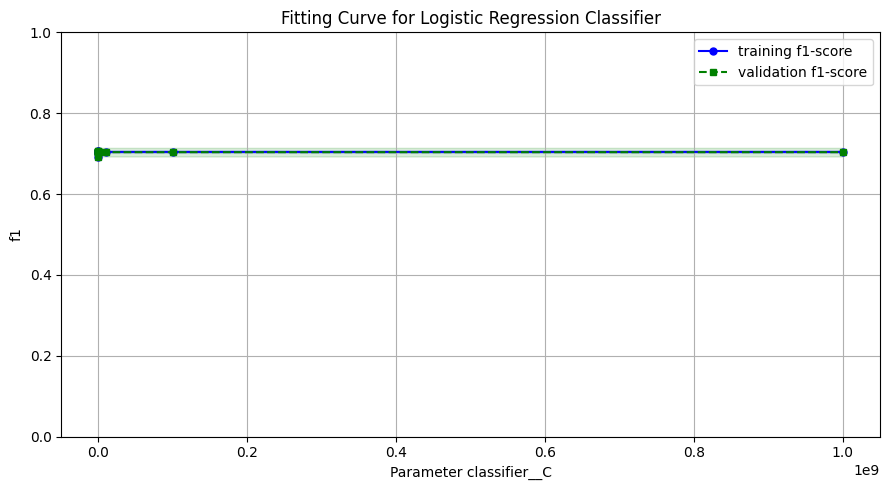

In [ ]:
# Fitting Graph: Logistic Regression Classifier
param_range = [0.00001, 0.0001, 0.001, 0.01, 0.1 ,1 ,10 ,100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
plot_fitting_curve(logit_pipe_tuned, "Fitting Curve for Logistic Regression Classifier", X_oversampled_train, y_oversampled_train,
                   'classifier__C', param_range,'f1', ylim=[0,1], cv=cv, n_jobs=4)
plt.show()

KeyboardInterrupt: 

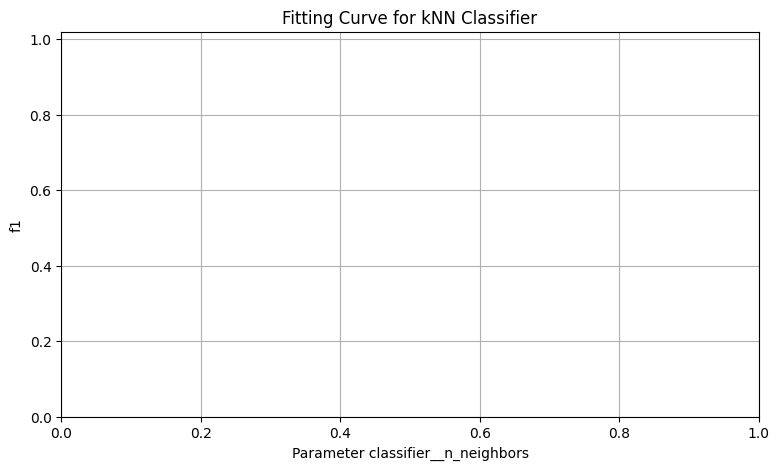

In [ ]:
# Fitting Graph: kNN Classifier

param_range = [i for i in range(3,22)]
plot_fitting_curve(knn_pipe_tuned, "Fitting Curve for kNN Classifier", X_oversampled_train, y_oversampled_train,
                   'classifier__n_neighbors', param_range,'f1', ylim=[0,1.02], cv=cv, n_jobs=4)
plt.show()

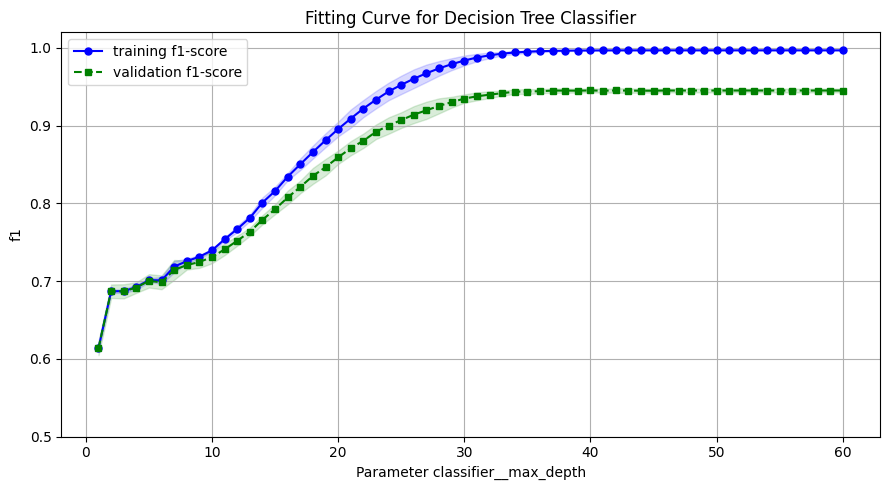

In [ ]:
# Fitting Graph: Decision Tree Classifier
param_range = [i for i in range(1,61)]
plot_fitting_curve(dt_pipe_tuned, "Fitting Curve for Decision Tree Classifier", X_oversampled_train, y_oversampled_train,
                   'classifier__max_depth',param_range,'f1', ylim=[0.5,1.02], cv=cv, n_jobs=4)
plt.show()

**Deployment**

Saving the Model

In [ ]:
def save_model(model, path="final_model.joblib"):
    # Think of this like "saving your progress in a video game"
    # It stores your trained model into a file (so you don’t lose it).
    dump(model, path)
    print(f"Saved model to {path}")

def load_model(path="final_model.joblib"):
    # This is like "loading your saved game"
    # It reopens the file so you can use the trained model again (for predictions).
    model = load(path)
    print(f"Loaded model from {path}")
    return model
